In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from mamba_model import Mamba, MambaConfig
import mamba_model
import argparse
from DataProcessing import HankelMatrices,HankelMatricesStates,  HankelMatricesSequences, Sequence2Sequence, Sequence2SequenceStates, Sequence2SequenceFuture, Sequence2SequencePast
import scipy.io
import scipy.io
from torch.utils.data import DataLoader, TensorDataset


In [2]:
#Load in Test data
u_test = np.load("uvec_test.npy")

x_test = np.load("xvec_test.npy")
N=20
u_test = torch.FloatTensor(u_test)
x_test = torch.FloatTensor(x_test)
print("u_test shape:"+str(u_test.shape))
print("y_test shape:"+str(x_test.shape))

#State Data
U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_test,x_test, N)
testX, testY = Sequence2SequenceStates(X0,U_0_Nm1,Y_1_N)




u_test shape:torch.Size([1600, 2])
y_test shape:torch.Size([1601, 4])
Hankel Matrices Generated


In [ ]:
#Load in Model    
class NetSequences(nn.Module):
    def __init__(self,in_dim,out_dim,L):
        super().__init__()
        D_model  = 4
        self.config = MambaConfig(d_model=D_model, n_layers=1, expand_factor = 1  , d_conv = 4, d_state = 4)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)
        return x.squeeze(0) 
    
    def total_entropy(self):
        return self.lin1.entropy() + self.MLP.entropy()

In [8]:
model = NetSequences(6,4,1)
model.load_state_dict(torch.load("State_dicts/ZOH_D4_dstate4_Conv4_N20",map_location=torch.device('cpu'))['model_state_dict'])


<All keys matched successfully>

In [11]:
model.lin1.entropy()

AttributeError: 'Linear' object has no attribute 'entropy'

In [33]:
model.eval()
mat = model(testX)
yhat = mat.detach().numpy()

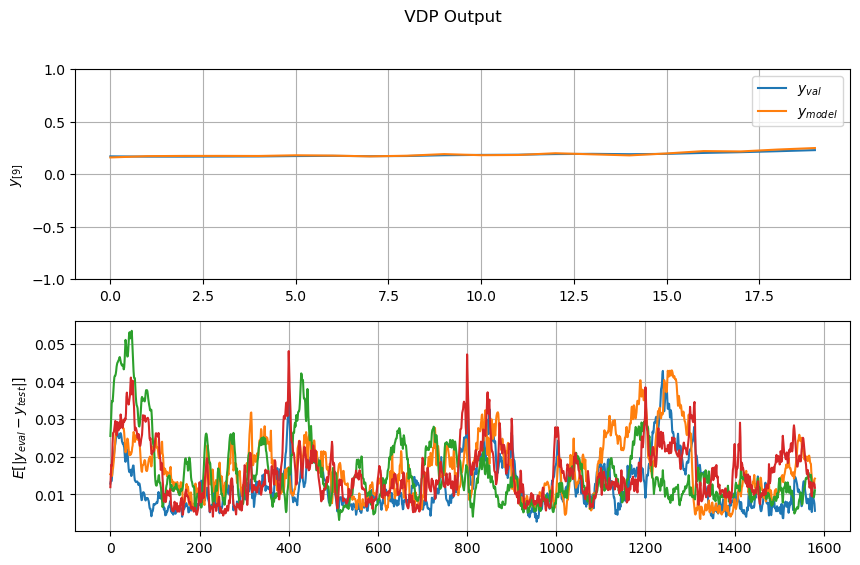

In [34]:
MAE = np.mean(np.abs(yhat - testY.numpy()),1)
RMAE = np.sqrt(MAE)
NRMAE = RMAE/(np.max(testY.numpy())-np.min(testY.numpy()))

N_step  = 1
index  = 100

fig, axs = plt.subplots(2, figsize=(10, 6))
fig.suptitle(" VDP Output")
axs[0].plot(testY[index ,:,0], label="$y_{val}$")
axs[0].plot(yhat[index ,:,0], label = "$y_{model}$")
axs[0].legend()
axs[0].grid()
axs[0].set_ylim(-1, 1)

axs[1].plot(MAE)
axs[0].set(ylabel="$y_{[9]}$")
#axs[1].set(ylabel="theta")
axs[1].set(ylabel="$E[|y_{eval}-y_{test}|]$")
axs[1].grid()
plt.show()
fig.savefig("MambaValidationSet"+".png", format='png', dpi=300)

In [35]:
TotalError = np.sum(MAE)
print("Total Error:"+str(TotalError))

Total Error:96.18182


In [36]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Calculate R-squared
r2_x1 = r2_score(testY[:,:,0].numpy(), yhat[:,:,0] )
r2_x2 = r2_score(testY[:,:,1].numpy(), yhat[:,:,1] )
r2_x3 = r2_score(testY[:,:,2].numpy(), yhat[:,:,2] )
r2_x4 = r2_score(testY[:,:,3].numpy(), yhat[:,:,3] )


print(f"R-squared on validation set: {r2_x1}")
print(f"R-squared on validation set: {r2_x2}")
print(f"R-squared on validation set: {r2_x3}")
print(f"R-squared on validation set: {r2_x4}")

R-squared on validation set: 0.9949241876602173
R-squared on validation set: 0.9896003007888794
R-squared on validation set: 0.995692253112793
R-squared on validation set: 0.9958692789077759


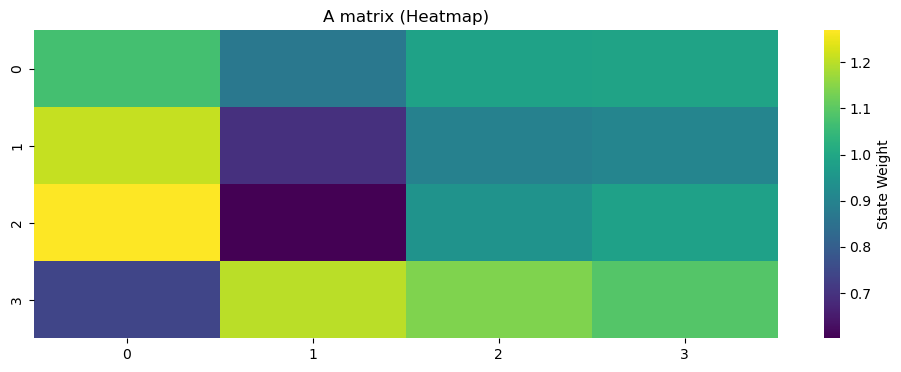

In [37]:
import seaborn as sns
# 2. Heatmap Style Attention Map

plt.figure(figsize=(12, 4))  # Shorter height for heatmap
sns.heatmap(torch.exp(model.mamba.layers[0].mixer.A_log).detach().numpy(),  # Reshape for heatmap
            cmap="viridis",  # Choose a suitable colormap
            xticklabels=True,  # Hide x-axis ticks if many time steps
            cbar_kws={'label': 'State Weight'}) # Add a colorbar with label


plt.title("A matrix (Heatmap)")
plt.show()

In [38]:
from scipy.io import savemat

#RMSBlock1
RMSWeight1 = model.mamba.layers[0].norm.weight.detach().numpy()

#RMSBlock2
RMSWeight2 = model.mamba.norm_f.weight.detach().numpy()

#Input Linear Projection to embedding
LinearInWeight = model.lin1.weight.detach().numpy()
LinearInBias = model.lin1.bias.detach().numpy()

#Expansion Linear Projection
LinearExpansionWeight  = model.mamba.layers[0].mixer.in_proj.weight.detach().numpy()
#No Bias

#Convolutional Layer
ConvWeight = model.mamba.layers[0].mixer.conv1d.weight.detach().numpy()
ConvBias = model.mamba.layers[0].mixer.conv1d.bias.detach().numpy()

#DeltaBC Projection
SelectionProjectionWeight = model.mamba.layers[0].mixer.x_proj.weight.detach().numpy()
#No Bias

#Sampling Time Projection
DeltaTProjectionWeight = model.mamba.layers[0].mixer.dt_proj.weight.detach().numpy()
DeltaTProjectionBias = model.mamba.layers[0].mixer.dt_proj.bias.detach().numpy()

##SSM Paramters
A = model.mamba.layers[0].mixer.A_log.detach().numpy()
D = model.mamba.layers[0].mixer.D.detach().numpy()


#Reduction Projection
LinearReductionWeight = model.mamba.layers[0].mixer.out_proj.weight.detach().numpy()
#No bias

# # #Output Projection
# LinearSequenceProjectionWeight = model.lin2.weight.detach().numpy()
# LinearSequenceProjectionBias = model.lin2.bias.detach().numpy()


#Output Projection
LinearOutputWeight = model.MLP.weight.detach().numpy()
LinearOutputBias = model.MLP.bias.detach().numpy()





# savemat(
#     "MambaParameters"+".mat",
#     {'LinearInWeight': LinearInWeight, 'LinearInBias': LinearInBias ,  'LinearExpansionWeight': LinearExpansionWeight,
#       'ConvWeight': ConvWeight, 'ConvBias': ConvBias, 'SelectionProjectionWeight': SelectionProjectionWeight,
#         'DeltaTProjectionWeight': DeltaTProjectionWeight, 'DeltaTProjectionBias': DeltaTProjectionBias, 
#          'A': A, 'D': D, 'LinearReductionWeight': LinearReductionWeight,  'LinearOutputWeight': LinearOutputWeight, 'LinearOutputBias': LinearOutputBias,'RMSWeight1': RMSWeight1 ,'RMSWeight2': RMSWeight2})

# savemat(
#     "MambaParameters"+".mat",
#     {'LinearInWeight': LinearInWeight, 'LinearInBias': LinearInBias ,  'LinearExpansionWeight': LinearExpansionWeight,
#       'ConvWeight': ConvWeight, 'ConvBias': ConvBias, 'SelectionProjectionWeight': SelectionProjectionWeight,
#         'DeltaTProjectionWeight': DeltaTProjectionWeight, 'DeltaTProjectionBias': DeltaTProjectionBias, 
#          'A': A, 'D': D, 'LinearReductionWeight': LinearReductionWeight,'LinearSequenceProjectionWeight': LinearSequenceProjectionWeight,  'LinearSequenceProjectionBias': LinearSequenceProjectionBias,   'LinearReductionWeight':LinearReductionWeight ,  'LinearOutputWeight': LinearOutputWeight, 'LinearOutputBias': LinearOutputBias,'RMSWeight1': RMSWeight1 ,'RMSWeight2': RMSWeight2})


In [39]:
from numpy import linalg as LA

print("Conditioning number of A: "+ str(LA.cond(A)))
print("Conditioning number of SelectionProjectionWeight: "+ str(LA.cond(SelectionProjectionWeight)))
print("Conditioning number of DeltaTProjectionWeight: "+ str(LA.cond(DeltaTProjectionWeight)))
print("Conditioning number of LinearInWeight: "+ str(LA.cond(LinearInWeight)))
print("Conditioning number of LinearExpansionWeight: "+ str(LA.cond(LinearExpansionWeight)))
print("Conditioning number of LinearReductionWeight: "+ str(LA.cond(LinearReductionWeight)))
print("Conditioning number of LinearOutputWeight: "+ str(LA.cond(LinearOutputWeight)))
print("Conditioning number of ConvWeight: "+ str(LA.cond(ConvWeight)))

Conditioning number of A: 181.90523
Conditioning number of SelectionProjectionWeight: 9.140601
Conditioning number of DeltaTProjectionWeight: 1.0
Conditioning number of LinearInWeight: 4.7616906
Conditioning number of LinearExpansionWeight: 3.0289958
Conditioning number of LinearReductionWeight: 18.616236
Conditioning number of LinearOutputWeight: 4.2369456
Conditioning number of ConvWeight: [1. 1. 1. 1.]


In [3]:
# Define constant pieces
ref1 = np.tile([0.650, 0.650, 0.652, 0.664], (500, 1))
ref2 = np.tile([0.300, 0.300, 0.301, 0.306], (500, 1))
ref3 = np.tile([0.500, 0.750, 0.305, 1.200], (500, 1))
ref4 = np.tile([0.900, 0.750, 1.062, 0.579], (500, 1))

# Concatenate them along the first axis (time steps)
xref_traj = np.concatenate((ref1, ref2, ref3,ref4), axis=0)  # Shape (100, 2)
xref_traj.shape

(2000, 4)

In [7]:
ksim = 2000-20
xref_traj[ksim:ksim+20].shape

(20, 4)

In [149]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys

N = 20  # horizon
ld = 20
nx = 4  # [theta, theta_dot]
ny = 4  # [theta, theta_dot]
nu = 2  # torque

   
# Set up optimization
opti = ca.Opti()
y = opti.variable(ny*N,)
u = opti.variable(nu*N,)

y.shape

(80, 1)

In [ ]:

batch_size, in_channels, width = inputs.shape
out_channels, _, kernel_size = ConvWeight.shape

# Calculate padding for 'same' padding
padding = (kernel_size - 1) // 2

# Pad the input tensor
padded_input = F.pad(inputs, (padding, padding))

In [21]:
ConvWeight.shape

(4, 1, 2)

In [22]:
(x_unfold*ConvWeight.T+ConvBias).shape

torch.Size([2, 20, 4])

In [27]:
# Create a dummy 1D convolutional layer (replace with your trained layer)
conv_layer = nn.Conv1d(in_channels=4, out_channels=4, kernel_size=2)

with torch.no_grad():
    conv_layer.weight.copy_(torch.tensor(ConvWeight,  dtype=torch.float32))
    conv_layer.bias.copy_(torch.tensor(ConvBias, dtype=torch.float32))

x = torch.tensor(np.ones((1,3,4)), dtype=torch.float32)

conv_layer(x.transpose(1,2))[:,:,:3].transpose(1,2)

tensor([[[ 0.2044, -1.1942, -0.7005, -1.2355],
         [ 0.2044, -1.1942, -0.7005, -1.2355]]], grad_fn=<TransposeBackward0>)

In [ ]:
model.mamba.layers[0].mixer.in_proj.weight.shape

In [29]:
x = torch.ones(1,3,4).transpose(1,2)
x = model.mamba.layers[0].mixer.conv1d(x)
x[:,:,1]

tensor([[ 0.3191, -0.4654,  0.4294,  0.0973]], grad_fn=<SelectBackward0>)

In [28]:
def manual_conv1d_same(input_tensor, weights, bias):
    """
    Manually applies a 1D convolutional layer with 'same' padding.

    Args:
        input_tensor (torch.Tensor): Input tensor of shape (batch_size, in_channels, width).
        weights (torch.Tensor): Convolutional weights of shape (out_channels, in_channels, kernel_size).
        bias (torch.Tensor): Convolutional bias of shape (out_channels,).

    Returns:
        torch.Tensor: Output tensor with the same width as the input.
    """
    batch_size, in_channels, width = input_tensor.shape
    out_channels, _, kernel_size = weights.shape

    # Calculate padding for 'same' padding
    padding = (kernel_size - 1) // 2

    # Pad the input tensor
    padded_input = F.pad(input_tensor, (padding, padding))

    # Initialize the output tensor
    output = torch.zeros(batch_size, out_channels, width)

    # Apply the convolution
    for i in range(width):
        for o in range(out_channels):
            # Extract the relevant slice of the padded input
            slice_input = padded_input[:, :, i:i + kernel_size]

            # Perform the convolution
            conv_result = torch.sum(slice_input * weights[o], dim=[1, 2]) + bias[o]
            output[:, o, i] = conv_result

    return output

# Example usage
input_tensor = torch.ones(1, 4, 3)
kernel_size = 2
in_channels = 4
out_channels = 4

# Initialize weights and bias (for demonstration purposes, simple random values)
weights = torch.randn(out_channels, in_channels, kernel_size)
bias = torch.randn(out_channels)

# Apply the manual convolution
output_manual = manual_conv1d_same(input_tensor, weights, bias)

# Verify with PyTorch's built-in Conv1d
conv1d = nn.Conv1d(in_channels, out_channels, kernel_size, padding='same', bias=True)
conv1d.weight = nn.Parameter(weights)
conv1d.bias = nn.Parameter(bias)
output_pytorch = conv1d(input_tensor)

print("Manual Convolution Output:")
print(output_manual)

print("\nPyTorch Conv1d Output:")
print(output_pytorch)

print("\nDifference between manual and pytorch:")
print(output_manual - output_pytorch)

Manual Convolution Output:
tensor([[[-2.2976, -2.2976, -2.2976],
         [-1.2358, -1.2358, -1.2358],
         [ 0.3182,  0.3182,  0.3182],
         [-1.5958, -1.5958, -1.5958]]])

PyTorch Conv1d Output:
tensor([[[-2.2976, -2.2976, -1.2716],
         [-1.2358, -1.2358,  1.9070],
         [ 0.3182,  0.3182,  1.9551],
         [-1.5958, -1.5958, -0.5676]]], grad_fn=<ConvolutionBackward0>)

Difference between manual and pytorch:
tensor([[[ 0.0000e+00,  0.0000e+00, -1.0260e+00],
         [-1.1921e-07, -1.1921e-07, -3.1428e+00],
         [ 0.0000e+00,  0.0000e+00, -1.6369e+00],
         [ 0.0000e+00,  0.0000e+00, -1.0281e+00]]], grad_fn=<SubBackward0>)


c:\Users\Michiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\conv.py:306: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ..\aten\src\ATen\native\Convolution.cpp:1032.)
  return F.conv1d(input, weight, bias, self.stride,


In [ ]:
from scipy.linalg import toeplitz
x = [0,0,1,1,1,1,1,1,1,1,0,0,0]
x = torch.tensor([float(i) for i in x]).unsqueeze(1).unsqueeze(0)


combined_W = []
for i in range(ConvWeight.shape[0]):
    kernel = ConvWeight[i, 0, :]
    # Create a Toeplitz-like matrix for each kernel.
    first_col = np.concatenate(([kernel[2]], [kernel[3]],[kernel[4]],[kernel[5]], [0], [0], [0], [0]))
    first_row = np.concatenate(([kernel[2]], [kernel[1]],[kernel[0]], np.zeros(10)))
    toeplitz_matrix = toeplitz(first_col, first_row)
    combined_W.append(toeplitz_matrix)

combined_W = np.concatenate(combined_W, axis=0)

In [ ]:
ConvBias

In [ ]:
x*torch.tensor(combined_W)

In [ ]:
combined_W*x

In [ ]:
x = [0,0,1,1,1,1,1,1,1,1,0,0,0]
x = torch.tensor([float(i) for i in x]).unsqueeze(1)

torch.tensor(combined_W).transpose(0,1)*x+ConvBias

In [ ]:
uN= np.array(torch.load("uNMPC.pt"))
u_ini_list = np.array(torch.load("u_ini.pt"))
y_ini_list = np.array(torch.load("y_ini.pt"))

In [ ]:
yN = []

for i in range(230):
    inputs = np.concatenate((u_ini_list[i].T, y_ini_list[i].T, uN[i]))
    inputs = torch.tensor(inputs, dtype=torch.float)
    yN.append(model(inputs.unsqueeze(0)).detach().numpy())

yN = np.array(yN).reshape(230,10)
print(yN.shape)

In [ ]:
#Sampling Time
Ts = 0.1

# Simulation time
time_range =24

# Simulation steps
L = round(time_range/Ts)

# Init time
t = np.arange(L+1)*Ts

mu = 1

# Initial state
x1_init = 1
x2_init = 1

x1 = np.zeros(L + 1)
x2 = np.zeros(L + 1)
u = np.zeros(L)
ref = np.zeros(L)

#Choose the reference
f = 0.1  # Frequency in Hz
A = 2
ref =  A*np.sin(2 * np.pi * f * t)

fig, axs = plt.subplots(2)
fig.suptitle("NMPC Casadi")
axs[0].plot(ref, label="$ref$")
axs[0].plot(yN[:,0] , label = "$NMPC$")
axs[0].legend()
axs[0].grid()
axs[0].set_ylim(-5, 5)

axs[1].plot(uN[:,0])
axs[0].set(ylabel="$y$")
#axs[1].set(ylabel="theta")
axs[1].set(ylabel="$u$")
axs[1].grid()
plt.show()
fig.savefig("MambaNMPCInput.png", format='png')

In [ ]:
model(inputs.unsqueeze(0))

In [ ]:
uN[:,0].shape